Exploratory Data Analysis (EDA) 

Step 1: Data collection and Import

Import required library tools and dataset. 

The Medical insurance dataset contains 7 columns with headings age, sex, bmi, children, smoker, region, and charges. The age column represents the age of the client, the sex column represents the gender of the client, bmi means body mass index of the client, the children column represents the number of children/ dependents the client has, the smoker column tells us the smoking status of the client, the region column tells us the geographical region of the client, lastly the charges column represents the medial insurance costs.

In [59]:
# import required library tools 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Set plot style to improve readability and visual stucture, by changing the background theme of graphs
sns.set_style("whitegrid")



In [60]:
# Load and Explore Dataset


# Load dataset/ read the dataset of "Medical Insurance dataset" in data. 
df = pd.read_csv(r"C:\Users\RUDZANI   NETHENGWE\Downloads\Medical Insurance Dataset\insurance.csv")

# Display top 5 rows
print("First 5 rows of dataset:")
print(df.head())


First 5 rows of dataset:
   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520


Exploratory Data Analysis (EDA)

Step 2: Data cleaning and quality checks 

Inspect data

Total records: there are 1338 entries (indeexed from 0-1337)
total columns: 7
columns with numerical data (4): age, bmi, children, and charges
columns with catagorical data (3): sex, smoker, and region
DataType: 
age column contains 64 integers 
sex column contains object datatype
bmi column contains 64 float 
childrent column contains 64 integers
smoker column contains object datatype
region column contains object datatype
charges column contains 64 float 

Missing values

according to the Non-Null count column in df.info() output, the dataset is completely clean regarding null values, every single column shows a count of 1338 non-null, which matches the total number of entries. 

step 3: descriptive Statistical summary

ages range from 18 to 64 years, with 39 as the average age. The range for bmi is 15.96 - 53.13, and the average of bmi is 30.66 which falls into obese category according to the standard BMI scales. The Medical insurances charges range from 1121 to 63770. 

Step 4: Data Visualisation and pattern trends

Distribution of Medical Insurance Charges:

The graph is skewed to the right (positively skewed). That means most people have relatively low charges (the left side of the graph is tall), while only a few have very high charges (the right tail stretches out). The highest bar is near the 0–10,000 charge range. This indicates the most common charge values are in that interval – lots of claims are for amounts less than 10,000.  As charges go above 10,000, the bars get shorter, meaning fewer and fewer observations have those higher values. By the time you get to 50,000–60,000, the frequency is almost zero. The data suggests insurance claims are typically small, with occasional large outliers. Models or analyses should account for this skewness (e.g., using log‑transformation or robust methods).

The Boxplot of charges shows that clients are usually charged between $1000 and 18000, with a median of approximately $8000, while a few values stretch far to thee right. Outliers were identified in the charges variable. However, these were retained as they represent real-world high-cost insurance cases and are important for building a realistic predictive model.

patterns in Data  

Bivariate analysis:

Figure 3 shows charges tend to increase with age, although the relationship looks roughly linear with some spread. Higher bmi is associated with higher charges, the spread is wider, indicating bmi's effect is less strong or more variable that age's. Medical charges appear slightly higher for individuals with more children but the trend is less clear than with age and bmi. Figure 4 tells us clients that smoke have charges ranging from $ 22000-42000, with a median of $ 34456.34845, which is more than of the ones that dont smoke. Figure 5 shows males are charged from $1100-20000 with a median of $9369.61575, the other points are outliers, females are charged $1600-15000 witha median of $9412.96250, the other points are outliers according to the boxplot, the medians and distributions between the two genders are almost similar, meaning theres no much difference.Figure 6 shows that some southeast region clients might be charged more because it has a higher max charge than the other regions, the charges at southeast region range from $1100-19000, and has a median of $9294.131950, the other points outside the box are outliers, but the medians of all regions are all almost similar. 

which variables influence charges:

Correlation matrix shows, Charges vs age has 0.3 diagonal value resulting in weak positive correlation, as age increases, charges tend to rise a little. older individuals tend to have slightly higher charges. Charges vs bmi has 0.2, resulting in a weak positive correlation, higher bmi is linked to modestly high charges. charges vs children has 0.068, this is a very weak positive correlation, the number of children has almost no linear effect on charges. Therefore smoker column has more influence on charges compared to the other numeric columns. 


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB
None

Missing Values:
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

Summary Statistics:
               age          bmi     children       charges
count  1338.000000  1338.000000  1338.000000   1338.000000
mean     39.207025    30.663397     1.094918  13270.422265
std      14.049960     6.098187     1.205493  12110.011237
min      18.000000    15.960000     0.000000   1121.873900
25%      27.0000

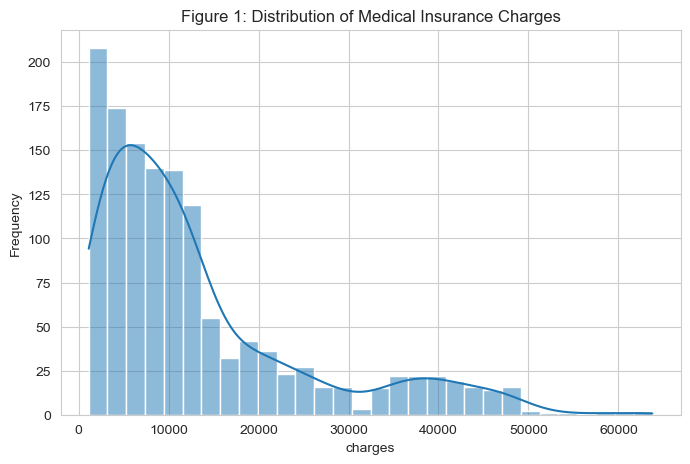

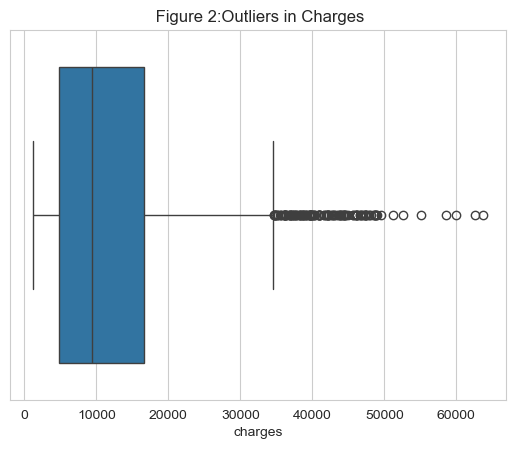

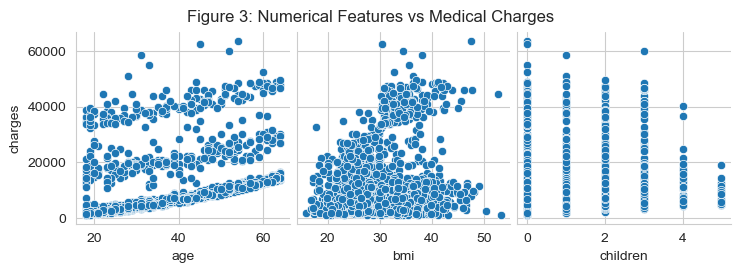

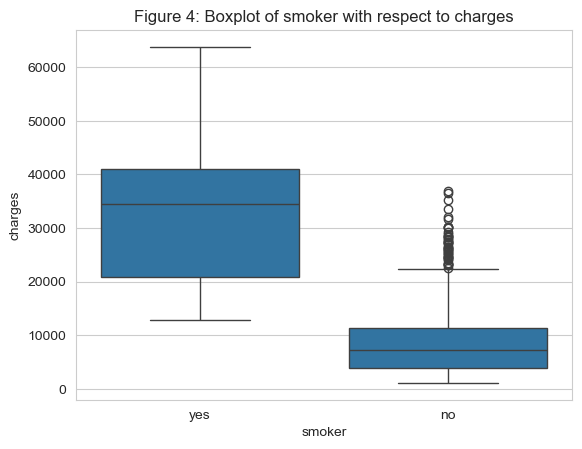

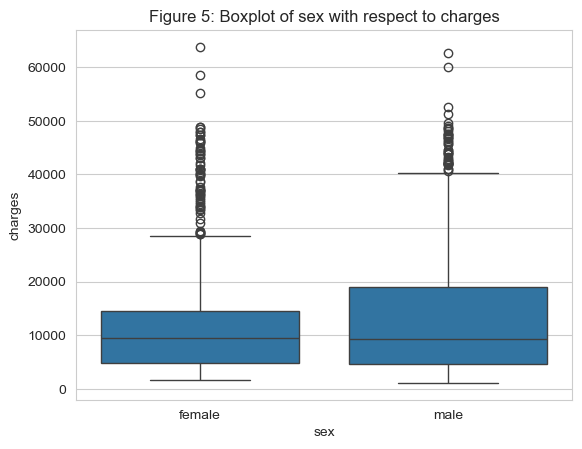

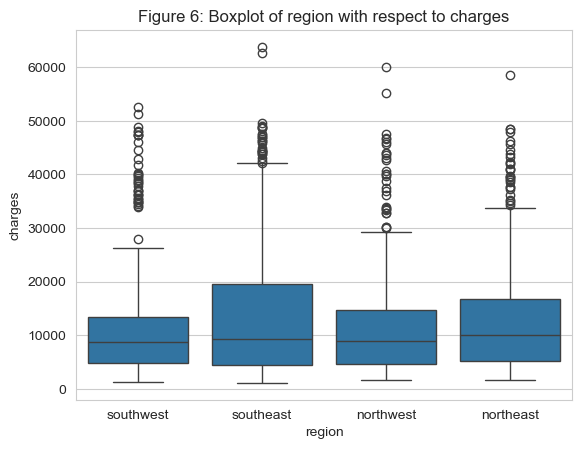

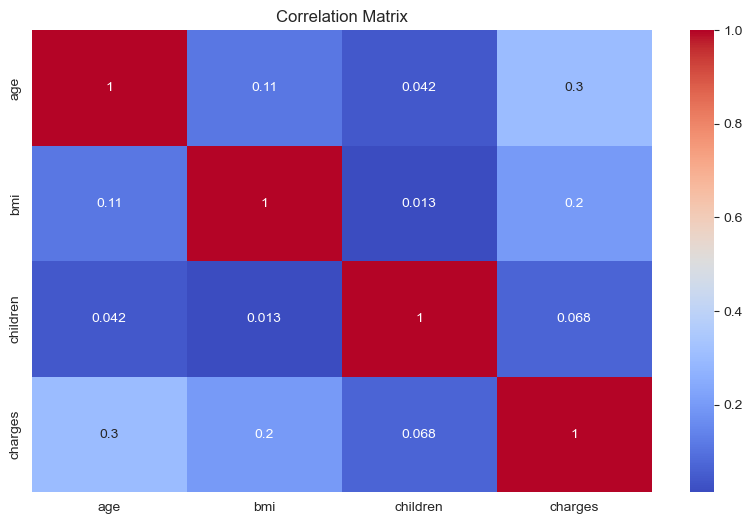

In [98]:
# Exploratory Data Analysis (EDA)


# Data inspection
# generate the information/ structure about the dataset 
print("\nDataset Info:")
print(df.info())

# Data cleaning

# For data cleaning check missing values 
print("\nMissing Values:")
print(df.isnull().sum())

# summarising statistics of the data

# Summary statistics
print("\nSummary Statistics:")
print(df.describe())

# Number of records
print("\nDataset Shape:", df.shape)


# Data Visualisation


import matplotlib.pyplot as plt
import seaborn as sns

# univariate analysis

#distribution of charges 
#create a new matplotlib figure with a size of 8 inches wide and 5 inches tall
plt.figure(figsize=(8,5))
#use sns to draw histogram of the charges column, kernel density estimate (kde)=True adds a smooth curve over the histogram to show data distribution. 
sns.histplot(df['charges'],kde=True)
plt.title("Figure 1: Distribution of Medical Insurance Charges")
plt.xlabel("charges")
plt.ylabel("Frequency")
plt.show()

# finding ourliers for charges 
sns.boxplot(x=df["charges"])
plt.title(" Figure 2:Outliers in Charges")
plt.show()


#Bivariate analysis 

#Numeric-numerical analysis

#pair plot
# indicate the numeric columns which will be x_vars, and the target variable (charges) will be y_vars 
numeric_cols=['age', 'bmi', 'children']
sns.pairplot(df, x_vars=numeric_cols, y_vars='charges', kind='scatter')
plt.suptitle('Figure 3: Numerical Features vs Medical Charges', y=1.05)
plt.show()

#Numeric-catagorical analysis 

#groupby the smokers to find the statistical analysis of the charges with response no & yes separately.
df.groupby('smoker')['charges'].describe()

#plot the box of charges with response(smoker) no & yes.
sns.boxplot(x=df['smoker'], y=df['charges'])
plt.title('Figure 4: Boxplot of smoker with respect to charges')
plt.show()

#groupby the sex to find the statistical analysis of the charges with response male & female separately.
df.groupby('sex')['charges'].median()

#plot the box of charges with response(sex) female & male.
sns.boxplot(x=df['sex'], y=df['charges'])
plt.title('Figure 5: Boxplot of sex with respect to charges')
plt.show()

#groupby the region to find the statistical analysis of the charges 
df.groupby('region')['charges'].median()

#plot the box of charges with the responses of region.
sns.boxplot(x=df['region'], y=df['charges'])
plt.title('Figure 6: Boxplot of region with respect to charges')
plt.show()

# Multivariate analysis  

# create a correlation matrix between numeric variables
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()




Exploratory Data analysis (EDA)

Step 5: Feature transformation and preparation

feature encoding 

Categorical features such as sex, smoker, and region were converted to numerical values because machine learning algorithms require numeric inputs. 

In [97]:
# Data Preprocessing


# Convert categorical variables to numeric using dummy variables
df_encoded = pd.get_dummies(df, drop_first=True, dtype=int)  # (Singh, 2025)

print("\nEncoded Dataset Preview:")
print(df_encoded.head())


Encoded Dataset Preview:
   age     bmi  children      charges  sex_male  smoker_yes  region_northwest  \
0   19  27.900         0  16884.92400         0           1                 0   
1   18  33.770         1   1725.55230         1           0                 0   
2   28  33.000         3   4449.46200         1           0                 0   
3   33  22.705         0  21984.47061         1           0                 1   
4   32  28.880         0   3866.85520         1           0                 1   

   region_southeast  region_southwest  
0                 0                 1  
1                 1                 0  
2                 1                 0  
3                 0                 0  
4                 0                 0  


Feature selection 

Step 6: feature selection using Recursive Feature Elimination with Cross-validation (RFECV) approach

The output indicates that 8 attributes were chosen as optimal. The selected features are age, BMI, children, sex_male, smoker_yes, region_northwest, region_souteast, and region_soutwest. 'charges' is the target variable. 

correlation matrix of the selected features vs charges: 
The association matrix shows that Charges versus Age has a diagonal value of 0.3, indicating a modest positive association; as age grows, charges tend to climb slightly. Older people tend to have slightly greater charges. Charges versus bmi has a 0.2 correlation, indicating a mild positive relationship; higher bmi is associated with modestly high charges. The correlation coefficient between charges and children is 0.068, indicating a very weak positive relationship; the number of children has essentially no linear effect on charges. Charges and sex_male has 0,057, indicating a very weak positive correlation; meaning being male has little to no influence on charges. Charges versus smoker_yes has a 0.79 correlation, which is a high positive correlation. Smokers face higher expenses than non-smokers. Charges versus region_northwest has -0.04, which is a very minor negative correlation, living in the northwest lowers charges. Region_southeast has a 0.074, indicating a very weak positive correlation; the southeast area is associated with mildly high charges. region_soutwest has -0.043, which is a very modest negative correlation; residing in the southwest reduces charges. As a result, smokers have a significant influence on charges.

optimal number of features:8
Automatically selected features; Index(['age', 'children', 'sex_male', 'smoker_yes', 'region_northwest',
       'region_southeast', 'region_southwest', 'bmi_smoker_interaction'],
      dtype='object')


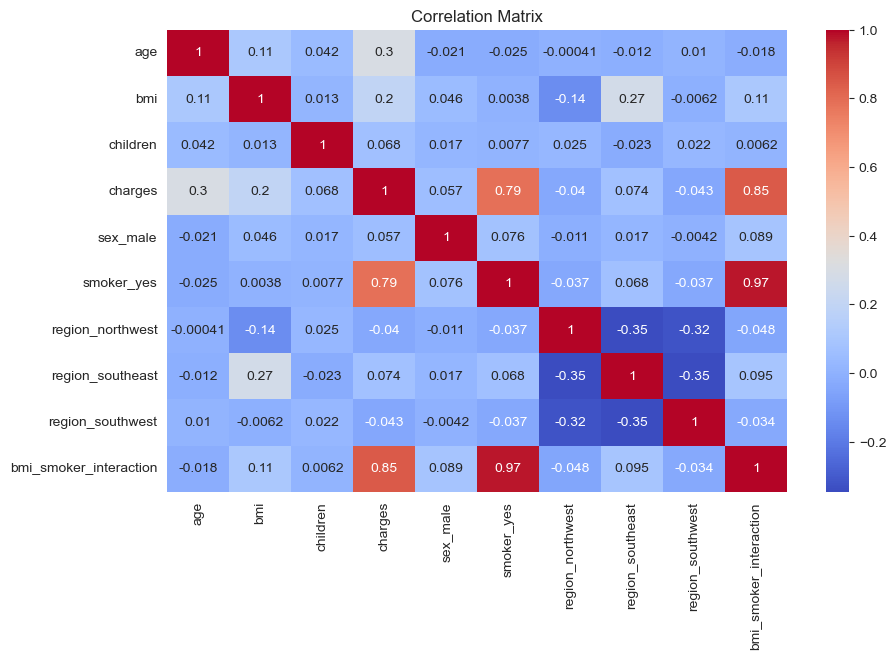

In [96]:
# Define Features and Target Variable

from sklearn.feature_selection import RFECV
from sklearn.linear_model import LinearRegression

# drop "charges" column 
X = df_encoded.drop("charges", axis=1)
y = df_encoded["charges"]

#initialise the model 
model=LinearRegression()

# Use RFECV, with minimum features to select as 1, and a cross validation of 10, meaning 10 different versions of the data will be tested
rfecv=RFECV(estimator=model, step=1, cv=10, scoring='neg_mean_squared_error')
fit=rfecv.fit(X,y)

# select number of features with highest accuracy score
print(f"optimal number of features:{rfecv.n_features_}")
selected_features= X.columns[rfecv.support_]
print("Automatically selected features;",selected_features)

# create a correlation matrix of selected features and charges 
plt.figure(figsize=(10,6))
sns.heatmap(df_encoded.corr(), annot=True, cmap="coolwarm")  #(Malamahadevan, 2025)
plt.title("Correlation Matrix")
plt.show()

Train Model

step 7: split dataset 

 The data was split in to test dataset(20%) and train dataset(80%), the training set was used to develop the model, while the testing set was used to assess its performance on previously unseen data. This method also assures that the model generalizes well while lowering the danger of overfitting. 

In [95]:
# Split Dataset


X_train_model, X_test_model, y_train_model, y_test_model = train_test_split(
X, y,
test_size=0.2,
random_state=42
)

print("\nTraining set size:", X_train_model.shape)
print("Testing set size:", X_test_model.shape)


Training set size: (1070, 8)
Testing set size: (268, 8)


Train model

step 8: Train linear regression model

The parameters used for this regression model are slope (coefficients) and intercept (β0), which define the best-fit line by minimizing the sum of squared residuals. β0 represents the intercept (-11931.219050326685), while β1, β2,..., βp represent the coefficients for each feature xi. 


In [94]:
# Train Linear Regression Model


model = LinearRegression()

#fit the model, fitting is the processes that makes linear regression algorithm learn the relationship between the input features(X) and y 
model.fit(X_train_model, y_train_model)

print("\nModel training completed.")

# To see the intercept (Beta 0)
print("Intercept:", model.intercept_)

# To see the coefficients (Beta 1, Beta 2, etc.)
print("coefficients:", model.coef_)




Model training completed.
Intercept: -11931.219050326685
coefficients: [ 2.56975706e+02  3.37092552e+02  4.25278784e+02 -1.85916916e+01
  2.36511289e+04 -3.70677326e+02 -6.57864297e+02 -8.09799354e+02]


Train Model

step 9: Making predictions 

The trained linear regression model was used to make 10 initial predictions on the testing dataset. These forecasts show the projected medical insurance costs based on the input features. predicted charges were: 8969.55027444  7068.74744287 36858.41091155  9454.67850053
 26973.17345656 10864.11316424   170.28084136 16903.45028662
  1092.43093614 11218.34318352. 

In [93]:
# Make Predictions

y_pred = model.predict(X_test_model)

print("\nFirst 10 Predictions:")
print(y_pred[:10])


First 10 Predictions:
[ 8969.55027444  7068.74744287 36858.41091155  9454.67850053
 26973.17345656 10864.11316424   170.28084136 16903.45028662
  1092.43093614 11218.34318352]


Train Model

step 10: Evaluating the model's performance 

The findings below show an MAE of 4181,194, indicating that the model's predictions are around 4181,194 units off on average. It prioritizes both little and major faults equally. The RMSE is 5796, 28, which is significantly greater than the MAE. This gap suggests that the model is generating significant errors on a few key data points. If the model made modest consistent mistakes, the MAE and RMSE would be much closer. The R squared score is 0.7836 (78.4%). This is a strong result, indicating that the model can explain 78% of the link between the specified features and charges. 22% of the variation in charges remains unexplained, possibly due to random noise or features not incorporated in the model. Age, BMI, children, and smoker_yes are highly significant (p < 0.05), indicating they are reliable predictors of cost. 

In [92]:
# Evaluate Model Performance

# generate the model metrics 
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


mae = mean_absolute_error(y_test_model, y_pred)
mse = mean_squared_error(y_test_model, y_pred)
r2 = r2_score(y_test_model, y_pred)
rmse = np.sqrt(mse)

# Print the results
print("\nModel Evaluation Metrics")
print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

# generate regression results, so that we can analyze the p values
import statsmodels.api as sm

# Extract only the p-values from the OLS (Ordinary least squares) model
p_values = stats_model.pvalues

# Create a clean display of features less than 0.05
print("Feature P-Values:")
print(p_values[p_values < 0.05].sort_values()) 

# Create a clean display of features greater than 0.05
print("\nInsignificant Features (p > 0.05):")
print(p_values[p_values >= 0.05])


Model Evaluation Metrics
MAE: 4181.19447375365
MSE: 33596915.85136145
RMSE: 5796.284659276273
R2 Score: 0.7835929767120724
Feature P-Values:
smoker_yes    9.774475e-286
age            6.310917e-70
const          1.815555e-25
bmi            4.109401e-24
children       6.063516e-03
dtype: float64

Insignificant Features (p > 0.05):
sex_male            0.960591
region_northwest    0.490070
region_southeast    0.223214
region_southwest    0.130563
dtype: float64


Train Model

step 11: model predicted charges vs actual values 

The scatterplot graph below shows that the model accurately predicts lower insurance costs but fails when charges rise, persistently underestimating high-cost claims. Points at the upper end of the x-axis are far below the red "perfect prediction" line. The presence of three different clusters indicates that other key features were not adequately captured, resulting in a lower R square score and more total error.


Actual vs Predicted:
      Actual Charges  Predicted Charges
764       9095.06825        8969.550274
887       5272.17580        7068.747443
890      29330.98315       36858.410912
1293      9301.89355        9454.678501
259      33750.29180       26973.173457


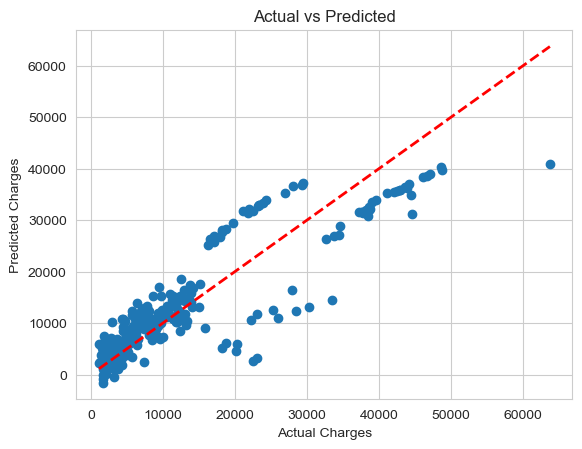

In [91]:
#compare values of actual vs predicted values 
results = pd.DataFrame({
"Actual Charges": y_test_model,
"Predicted Charges": y_pred
})

print("\nActual vs Predicted:")
print(results.head())

# plot the graph showing actual vs predicted values 
plt.plot([y_test_model.min(), y_test_model.max()], [y_test_model.min(), y_test_model.max()], color='red', lw=2, linestyle='--')
plt.scatter(y_test_model, y_pred)
plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges")
plt.title("Actual vs Predicted")
plt.show()


Retrain the model 

step 12: select features 

An interactive feature for bmi_smoker was created. The interaction represents the combined risk of these two factors. Being a smoker with a high BMI is far more harmful than one factor alone. The resulting model assigned specific coefficients to each feature, including the new interaction term. the parameters changed. Intercept: -2684.314113083008
coefficients: 2.63517683e+02  9.34831546e+00  4.61809149e+02 -2.07995597e+04
  1.45633718e+03

In [90]:
#retraining the linear regression model
#  Create the Interaction Feature
df_encoded['bmi_smoker_interaction'] = df_encoded['bmi'] * df_encoded['smoker_yes']

# Define the 5 features for the improved model
features_imp = ['age', 'bmi', 'children', 'smoker_yes', 'bmi_smoker_interaction']
X_imp = df_encoded[features_imp]

# Split using unique 'imp' names
X_train_imp, X_test_imp, y_train_imp, y_test_imp = train_test_split(X_imp, y, test_size=0.2, random_state=42)

# Retrain the Model
from sklearn.linear_model import LinearRegression
model_imp = LinearRegression()
model_imp.fit(X_train_imp, y_train_imp)



,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [89]:
#  show the Intercept (Beta 0)
print("Intercept:", model_imp.intercept_)

# show the coefficients 
print("coefficients:", model_imp.coef_)

Intercept: -2684.314113083008
coefficients: [ 2.63517683e+02  9.34831546e+00  4.61809149e+02 -2.07995597e+04
  1.45633718e+03]


Retrain the model 

step 13: Predictions and metrics of the retrained model 

The model's explanatory power increased significantly, with the R square increasing from 0.78 to 0.86. This update significantly lowered the Mean Absolute Error by more than 40%, demonstrating that the model is now far more sensitive to the complex risk variables that underlie high medical costs. The retrained model indicates that age, children, smoker_yes, and bmi_smoker_interaction features are highly statistically significant (p-values < 0.05). Notably, the bmi_smoker_interaction p-value demonstrates that the combination of smoking and a high BMI is a good predictor of medical charges.

In [88]:
#  Predict and Calculate Metrics for retrained model

# Generate predictions using the improved/ retrained model
y_pred_imp = model_imp.predict(X_test_imp)
print("\nFirst 10 Predictions:")
print(y_pred_imp[:10])

#Calculate the Metrics
r2_imp = r2_score(y_test_imp, y_pred_imp)
mae_imp = mean_absolute_error(y_test_imp, y_pred_imp)
mse_imp = mean_squared_error(y_test_imp, y_pred_imp)
rmse_imp = np.sqrt(mse_imp)

# Print the results
print("--- Improved Model Metrics ---")
print(f"Mean Absolute Error (MAE): {mae_imp}")
print(f"Mean Squared Error (MSE): {mse_imp}")
print(f"Root Mean Squared Error (RMSE): {rmse_imp}")
print(f"R2 Score: {r2_imp}")

# generate regression results, so that we can analyze the p values
import statsmodels.api as sm

# Statsmodels requires a constant (intercept) to be added manually
X_train_const = sm.add_constant(X_train_imp) 

# Fit the OLS model using the training data
ols_model_imp = sm.OLS(y_train_imp, X_train_const).fit()

# Print a summary of which features are statistically significant
print("\nStatistically Significant Features (p < 0.05):")
print(ols_model_imp.pvalues[ols_model_imp.pvalues < 0.05])





First 10 Predictions:
[10332.94377851  7082.95891861 32786.21247227 11063.59915066
 28307.6431837   7138.13900398  2532.99919368 14535.16552055
  4855.81339578 11881.68298982]
--- Improved Model Metrics ---
Mean Absolute Error (MAE): 2783.93354482586
Mean Squared Error (MSE): 21293425.767070208
Root Mean Squared Error (RMSE): 4614.480010474659
R2 Score: 0.8628431577993374

Statistically Significant Features (p < 0.05):
const                      4.625773e-03
age                       3.536248e-104
children                   2.159955e-04
smoker_yes                 7.792892e-27
bmi_smoker_interaction    2.518034e-102
dtype: float64


Retrain the model 

step 14: Model predicted charges vs actual values

The Actual vs. predicted figure supports the improved model's performance by demonstrating a good linear correlation between predicted values and actual ones. 


Actual vs Predicted:
      Actual Charges  Predicted Charges
764       9095.06825       10332.943779
887       5272.17580        7082.958919
890      29330.98315       32786.212472
1293      9301.89355       11063.599151
259      33750.29180       28307.643184


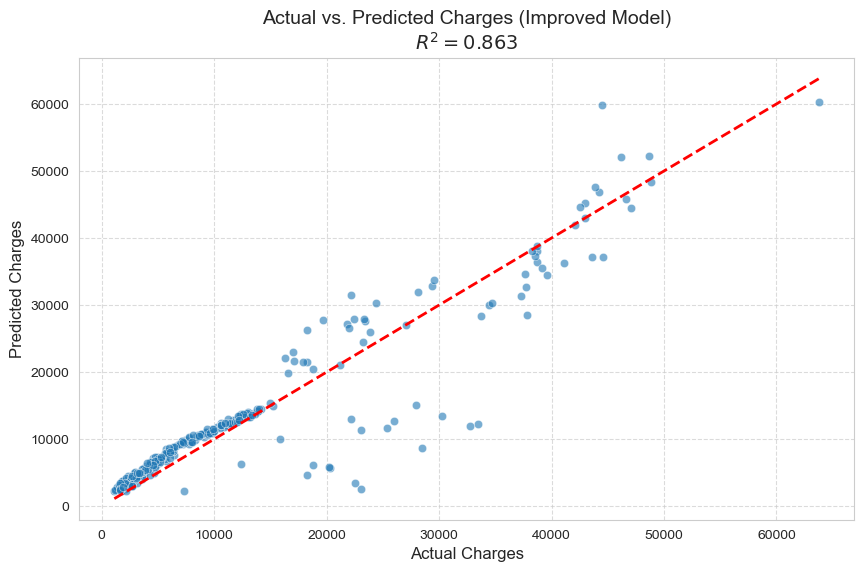

In [86]:
#compare values of actual vs predicted values 
results = pd.DataFrame({
"Actual Charges": y_test_imp,
"Predicted Charges": y_pred_imp
})

print("\nActual vs Predicted:")
print(results.head())

# Create the figure
plt.figure(figsize=(10, 6))

# Plot Actual vs Predicted values
sns.scatterplot(x=y_test_imp, y=y_pred_imp, alpha=0.6)

# Add the 'Perfect Prediction' line (the diagonal)
plt.plot([y_test_imp.min(), y_test_imp.max()], [y_test_imp.min(), y_test_imp.max()], color='red', lw=2, linestyle='--')

# Add labels and title
plt.title(f'Actual vs. Predicted Charges (Improved Model)\n$R^2 = {r2_imp:.3f}$', fontsize=14)
plt.xlabel('Actual Charges', fontsize=12)
plt.ylabel('Predicted Charges', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)

plt.show()

REFERENCE LIST

Malamahadevan, 2025. Step-by-Step Exploratory Data Analysis (EDA) using Python. [online] Analytics Vidhya. Available at: https://www.analyticsvidhya.com/blog/2022/07/step-by-step-exploratory-data-analysis-eda-using-python/. [Accessed 25 March 2026]

Simplilearn, n.d. Exploratory Data Analysis (EDA) Learning Unit 1. [online] Available at: https://www.simplilearn.com/tutorials/data-analytics-tutorial/exploratory-data-analysis#what_is_exploratory_data_analysis. [Accessed 25 March 2026]

Singh, R., 2025. Why use get_dummies with drop_first in Machine Learning. [online] Medium. Available at: https://medium.com/@randhirsingh23/why-use-get-dummies-with-drop-first-in-machine-learning-16be85d3899c. [Accessed 26 March 2026]